# Specific Task 2.4 Train/Evaluate advanced model

In [5]:
import os, re, json, math, unicodedata, warnings
from collections import OrderedDict
from dataclasses import dataclass, asdict
from functools import partial
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

# Reading Data

In [6]:
def read_txt(path):
    rows = []
    with open(path, "r", encoding="utf-8") as fh:
        lines = fh.read().splitlines()
    for line in lines:
        parts = line.split(": ")
        if len(parts) < 4:
            continue
        rows.append({
            "Event Type": parts[0].strip(),
            "Interaction": parts[1].strip(),
            "Feynman Diagram": parts[2].strip(),
            "Amplitude": parts[-2].strip(),
            "Squared Amplitude": parts[-1].strip()
        })
    return rows

In [7]:
base_dir = "/kaggle/input/datasets/arnavtripathi1/symba-test-data"

qed_data = []
qcd_data = []

for file in os.listdir(base_dir):
    path = os.path.join(base_dir, file)
    rows = read_txt(path)
    if "QED" in file:
        qed_data.extend(rows)
    if "QCD" in file:
        qcd_data.extend(rows)

In [8]:
qed_df = pd.DataFrame(qed_data)
qcd_df = pd.DataFrame(qcd_data)

print("QED dataset size:", len(qed_df))
print("QCD dataset size:", len(qcd_df))

QED dataset size: 360
QCD dataset size: 234


# Train-Val-Test Split

In [9]:
from sklearn.model_selection import train_test_split

# split QED
qed_train, temp_df = train_test_split(qed_df, test_size=0.2, random_state=42, shuffle=True)
qed_val, qed_test = train_test_split(temp_df, test_size=0.5, random_state=42, shuffle=True)

# split QCD
qcd_train, temp_df = train_test_split(qcd_df, test_size=0.2, random_state=42, shuffle=True)
qcd_val, qcd_test = train_test_split(temp_df, test_size=0.5, random_state=42, shuffle=True)

print(f"QED -> Train size : {len(qed_train)}, Validation size : {len(qed_val)}, Test size : {len(qed_test)}")
print(f"QCD -> Train size : {len(qcd_train)}, Validation size : {len(qcd_val)}, Test size : {len(qcd_test)}")

qed_train.to_csv("qed_train.csv")
qed_val.to_csv("qed_val.csv")
qed_test.to_csv("qed_test.csv")

qcd_train.to_csv("qcd_train.csv")
qcd_val.to_csv("qcd_val.csv")
qcd_test.to_csv("qcd_test.csv")

QED -> Train size : 288, Validation size : 36, Test size : 36
QCD -> Train size : 187, Validation size : 23, Test size : 24


# Tokenizer

In [10]:
import json
from collections import Counter, OrderedDict
import re
import unicodedata
import warnings
from typing import List, Tuple, Dict, Any
from tqdm.auto import tqdm

class PittTokenizer:
    """Physics-informed tokenizer for amplitudes and squared amplitudes expressions."""
    def __init__(
        self,
        index_token_pool_size = 120,
        momentum_token_pool_size = 10,
        particle_index_pool_size = 10,
        special_symbols = None,
        unk_idx = 3
    ):
        self.index_pool_size = int(index_token_pool_size)
        self.momentum_pool_size = int(momentum_token_pool_size)
        self.particle_index_pool_size = int(particle_index_pool_size)
        self.index_tokens = [f"INDEX_{i}" for i in range(self.index_pool_size)]
        self.momentum_tokens = [f"MOMENTUM_{i}" for i in range(self.momentum_pool_size)]
        self.pindex_tokens = [f"PINDEX_{i}" for i in range(self.particle_index_pool_size)]
        self.special_symbols = special_symbols or ["<BOS>", "<PAD>", "<EOS>", "<UNK>", "<SEP>"]
        self.unk_idx = unk_idx

        # regex patterns
        self._re_whitespace = re.compile(r"\s+")
        self._re_unicode_norm = unicodedata.normalize
        self._re_gamma_token = re.compile(r'gamma_\{([^}]+)\}')
        self._re_wavefunction = re.compile(r'\b([A-Za-z]+)_\{([^}]+)\}\(([^)]+)\)(_[A-Za-z]+)(\^CONJ)?')
        self._re_momentum = re.compile(r'\bp_(\d+)\b')
        self._re_mandelstam = re.compile(r'\bs_(\d+)\b')
        self._re_mass = re.compile(r'\bm_[A-Za-z]+\b')
        self._re_particle_index = re.compile(r'\b([ijkl])_(\d+)\b')
        # candidate indices excluding mass/momentum/mandelstam/particle indices
        self._re_index_candidate = re.compile(r'(?!p_)(?!s_)(?!m_)(?![ijkl]_)[A-Za-z%\\]+_\d+')
        # operators and separators
        self._operators = list('/+-*^,{}()[]:=') 

    # ---- Normalization Utilities ----
    def normalize_unicode_and_whitespace(self, expression):
        """Apply unicode normalization and collapse whitespace."""
        if expression is None:
            return ""
        expr = self._re_unicode_norm("NFKC", expression)
        expr = self._re_whitespace.sub(" ", expr).strip()
        return expr

    def fix_brace_spaces(self, expr):
        """Canonicalize spacing inside {...} blocks:"""
        def clean(match):
            inner = match.group(1)
            inner = inner.strip()
            inner = re.sub(r'\s*,\s*', ',', inner)
            inner = re.sub(r'\s*\+\s*', '+', inner)
            inner = re.sub(r'\s*-\s*', '-', inner)
            return '{' + inner + '}'
        return re.sub(r'\{([^}]*)\}', clean, expr)

    def preprocess_expression(self, expression):
        """Canonicalize common physics tokens and simple formatting."""
        expr = self.normalize_unicode_and_whitespace(str(expression))
        expr = expr.replace("me", "m_e")
        expr = expr.replace("reg_prop", "REG_PROP")
        expr = expr.replace("(*)", "CONJ")
        expr = expr.replace("+-", "-").replace("-+", "-")
        expr = re.sub(r'\s*\*\s*', '*', expr)
        expr = re.sub(r'\s*/\s*', '/', expr)
        expr = re.sub(r'\s*\^\s*', '^', expr)
        expr = re.sub(r'\s*\+\s*', ' + ', expr)
        expr = re.sub(r'\s*-\s*', ' - ', expr)
        expr = re.sub(r'\s+', ' ', expr).strip()
        expr = self.fix_brace_spaces(expr)
        return expr

    def physics_aware_replace(self, expr):
        """Canonicalize momentum, mandelstam, masses, conjugation, imaginary unit and constants."""
        e = expr
        e = self._re_mandelstam.sub(r"MANDELSTAM_\1", e)
        e = self._re_momentum.sub(r"P_\1", e)
        e = self._re_mass.sub(lambda m: m.group(0), e)
        e = re.sub(r'\bi\b(?!\w)', 'I_UNIT', e)
        e = re.sub(r'\be\b(?=\^|[+\-*/()| ,])', 'E_CHARGE', e)
        e = re.sub(r'\bg\b(?=\^|[+\-*/()| ,])', 'G_COUPLING', e)
        return e

    # ---- Index Normalisation and Mapping ----
    def extract_pair_index_order(self, amp, sqamp):
        """Return ordered unique candidate indices, particle indices and momentum matches for a pair."""
        combined = amp + " || " + sqamp
        # find regular index candidates
        seen = OrderedDict()
        for m in self._re_index_candidate.finditer(combined):
            key = m.group(0)
            if key not in seen:
                seen[key] = None
        index_candidates = list(seen.keys())
        # particle indices
        pseen = OrderedDict()
        for m in self._re_particle_index.finditer(combined):
            key = m.group(0)
            if key not in pseen:
                pseen[key] = None
        particle_candidates = list(pseen.keys())
        # momentum occurrences
        mseen = OrderedDict()
        for m in self._re_momentum.finditer(combined):
            key = m.group(0)
            if key not in mseen:
                mseen[key] = None
        momentum_candidates = list(mseen.keys())

        return index_candidates, particle_candidates, momentum_candidates

    def build_deterministic_mapping(self, index_candidates, particle_candidates, momentum_candidates):
        """Create deterministic mapping to INDEX_/PINDEX_/MOMENTUM_ tokens."""
        mapping = {}
        for i, old in enumerate(index_candidates):
            if i >= self.index_pool_size:
                raise RuntimeError("index_pool exhausted; increase index_token_pool_size")
            mapping[old] = self.index_tokens[i]
        for i, old in enumerate(particle_candidates):
            if i >= self.particle_index_pool_size:
                raise RuntimeError("particle_index_pool exhausted; increase particle_index_pool_size")
            mapping[old] = self.pindex_tokens[i]
        for i, old in enumerate(momentum_candidates):
            if i >= self.momentum_pool_size:
                raise RuntimeError("momentum_pool exhausted; increase momentum_token_pool_size")
            mapping[old] = self.momentum_tokens[i]
        return mapping

    def apply_mapping_to_text(self, text, mapping):
        """Replace all full-token matches in text using provided mapping."""
        if not mapping:
            return text
        for old in sorted(mapping.keys(), key=len, reverse=True):
            new = mapping[old]
            text = text.replace(old, new)
        return text

    def normalize_pair_indices(self, ampl, sqamp):
        """Pre-processes and returns strictly mapped strings."""
        amp_p = self.preprocess_expression(ampl)
        sqamp_p = self.preprocess_expression(sqamp)
        idx_cands, p_cands, m_cands = self.extract_pair_index_order(amp_p, sqamp_p)
        mapping = self.build_deterministic_mapping(idx_cands, p_cands, m_cands)
        amp_mapped = self.apply_mapping_to_text(amp_p, mapping)
        sqamp_mapped = self.apply_mapping_to_text(sqamp_p, mapping)
        amp_final = self.physics_aware_replace(amp_mapped)
        sqamp_final = self.physics_aware_replace(sqamp_mapped)
        amp_final = self.fix_brace_spaces(amp_final)
        sqamp_final = self.fix_brace_spaces(sqamp_final)
        return amp_final, sqamp_final, mapping

    def normalize_dataframe_pairs(self, df, keep_mapping=False):
            """Applies normalization to dataframes."""
            records = []
            for _, row in tqdm(df.iterrows(), total=len(df), desc="Normalizing DataFrame Pairs"):
                ampl = row.get("Amplitude", "")
                sqamp = row.get("Squared Amplitude", "")
                ampl_norm, sqamp_norm, mapping = self.normalize_pair_indices(ampl, sqamp)
                rec = row.to_dict()
                rec["Amplitude_norm"] = ampl_norm
                rec["Squared_Amplitude_norm"] = sqamp_norm
                if keep_mapping:
                    rec["index_mapping"] = json.dumps(mapping)
                records.append(rec)
            return pd.DataFrame.from_records(records)
    
    # ---- Splitting Tokens ----
    def expand_structured_tokens(self, text):
        """Expand structured physics tokens by splitting their index/momentum arguments."""
        def _expand_gamma(m):
            inner = m.group(1)
            parts = [p.strip() for p in inner.split(',')]
            return f"GAMMA_{len(parts)} " + " , ".join(parts)
    
        def _expand_wavefunction(m):
            name  = m.group(1).upper()
            inner = m.group(2)
            mom   = m.group(3)
            vtype = m.group(4)
            conj  = " CONJ" if m.group(5) else ""
            parts = [p.strip() for p in inner.split(',')]
            return f"{name}_{len(parts)} " + " , ".join(parts) + f" {mom} {vtype}{conj}"
    
        text = self._re_wavefunction.sub(_expand_wavefunction, text)
        text = self._re_gamma_token.sub(_expand_gamma, text)
        text = re.sub(r'(MOMENTUM_\d+)_(INDEX_\d+)', r'\1 \2', text)
        return text
        
    def split_tokens(self, text):
        """Split on operators and keep tokens intelligible to transformer."""
        t = text
        for op in self._operators:
            t = t.replace(op, f' {op} ')
        # more frequent fractions kept intact
        top_fracs = ["1/2", "1/16", "1/9", "4/9", "1/448", "16/7", "1/144", "1/3", "1/6", "8/7"]
        for f in top_fracs:
            t = re.sub(rf"\b{f.replace('/', ' / ')}\b", f, t)
        t = re.sub(r'\s+', ' ', t).strip()
        tokens = [tok for tok in t.split(' ') if tok]
        return tokens

    def src_tokenize(self, ampl_norm):
        """Tokenize Source expression."""
        if not ampl_norm: return []
        try:
            expanded_str = self.expand_structured_tokens(str(ampl_norm))
            tokens = self.split_tokens(expanded_str)
            return tokens
        except Exception as e:
            warnings.warn(f"Source tokenization failed for '{ampl_norm}': {e}")
            return [self.special_symbols[self.unk_idx]]

    def tgt_tokenize(self, sqamp_norm):
        """Tokenize Target expression."""
        if not sqamp_norm: return []
        try:
            expanded_str = self.expand_structured_tokens(str(sqamp_norm))
            tokens = self.split_tokens(expanded_str)
            return tokens
        except Exception as e:
            warnings.warn(f"Target tokenization failed for '{sqamp_norm}': {e}")
            return [self.special_symbols[self.unk_idx]]

    # ---- Build Vocabularies ----
    def get_base_vocab(self):
        """Returns a set of index, momentum and pindex tokens."""
        base = set(self.special_symbols)
        base.update(self.index_tokens)
        base.update(self.momentum_tokens)
        base.update(self.pindex_tokens)
        return base

    def build_src_vocab(self, df: pd.DataFrame):
        """Build Source Vocabulary."""
        src_vocab = self.get_base_vocab()
        for s in tqdm(df["Amplitude_norm"].astype(str), total=len(df), desc="Building src vocab"):
            src_vocab.update(self.src_tokenize(s))
        return src_vocab

    def build_tgt_vocab(self, df: pd.DataFrame):
        """Build Target Vocabulary."""
        tgt_vocab = self.get_base_vocab()
        for s in tqdm(df["Squared_Amplitude_norm"].astype(str), total=len(df), desc="Building tgt vocab"):
            tgt_vocab.update(self.tgt_tokenize(s))
        return tgt_vocab

    def save_vocab(self, path, src_vocab, tgt_vocab):
        """Save Vocabularies to JSON file."""
        out = {
            "special_symbols": self.special_symbols,
            "src_vocab": sorted(list(src_vocab)),
            "tgt_vocab": sorted(list(tgt_vocab))
        }
        with open(path, "w", encoding="utf-8") as fh:
            json.dump(out, fh, ensure_ascii=False, indent=2)

    def load_vocab(self, path):
        """Load Vocabularies from JSON file."""
        with open(path, "r", encoding="utf-8") as fh:
            return json.load(fh)

In [11]:
class SymbolicVocab:
    """Simple vocab mapping between tokens and indices."""
    def __init__(self, tokens, special_symbols):
        remaining_tokens = sorted(list(set(tokens) - set(special_symbols)))
        self.token_list = special_symbols + remaining_tokens
        self.token_to_idx = {tok: i for i, tok in enumerate(self.token_list)}
        self.idx_to_token = {i: tok for tok, i in self.token_to_idx.items()}
        self.bos_idx = self.token_to_idx.get("<BOS>", 0)
        self.pad_idx = self.token_to_idx.get("<PAD>", 1)
        self.eos_idx = self.token_to_idx.get("<EOS>", 2)
        self.unk_idx = self.token_to_idx.get("<UNK>", 3)
        self.sep_idx = self.token_to_idx.get("<SEP>", 4)
        
    def encode(self, tokens):
        return [self.token_to_idx.get(tok, self.unk_idx) for tok in tokens]

    def decode(self, indices, include_special_tokens = True):
        if include_special_tokens:
            return [self.idx_to_token.get(i, "<UNK>") for i in indices]
        
        specials = {self.pad_idx, self.bos_idx, self.eos_idx, self.sep_idx}
        return [self.idx_to_token.get(i, "<UNK>") for i in indices if i not in specials]

    def __len__(self):
        return len(self.token_list)

# Architecture

In [ ]:
@dataclass
class MAGConfig:
    """Hyperparameters for SYMBA-MAG encoder-decoder."""
    vocab_size:      int
    dim:             int   = 256
    depth:           int   = 6
    heads:           int   = 8
    ff_expansion:    float = 4.0
    dropout:         float = 0.1
    swa_window_size: int   = 64   

    mem_depth:       int   = 2
    mem_expansion:   float = 4.0
    mem_lr:          float = 0.01
    mem_momentum:    float = 0.9
    mem_decay:       float = 0.01
    mem_chunk_size:  int   = 16   
    pad_idx:         int   = 1

    def __post_init__(self):
        assert self.dim % self.heads == 0,   'dim must be divisible by heads'
        assert self.mem_chunk_size > 0,      'mem_chunk_size > 0 prevents causal leakage'
        assert self.swa_window_size > 0,     'swa_window_size must be positive'

    def to_dict(self) -> dict: return asdict(self)

class RMSNorm(nn.Module):
    """Root-mean-square layer normalisation (no bias)."""
    def __init__(self, dim: int, eps: float = 1e-6):
        super().__init__()
        self.eps = eps
        self.g   = nn.Parameter(torch.ones(dim))
    def forward(self, x):
        return x * torch.rsqrt(x.pow(2).mean(-1, keepdim=True) + self.eps) * self.g


class PositionalEncoding(nn.Module):
    """Fixed sinusoidal positional encoding. """
    def __init__(self, d_model, dropout = 0.1, max_len = 2048):
        super().__init__()
        self.drop = nn.Dropout(dropout)
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(max_len, dtype=torch.float).unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2, dtype=torch.float) * (-math.log(10_000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x, offset = 0):
        return self.drop(x + self.pe[:, offset:offset + x.size(1)])


class FeedForward(nn.Module):
    """Position-wise feed-forward with GELU activation."""
    def __init__(self, dim, expansion = 4.0, dropout = 0.0):
        super().__init__()
        H = int(dim * expansion)
        self.net = nn.Sequential(
            nn.Linear(dim, H), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(H, dim), nn.Dropout(dropout),
        )
    def forward(self, x): return self.net(x)

# Memory Module

In [ ]:
class MemoryMLP(nn.Module):
    """Small MLP (associative store)."""
    def __init__(self, dim, depth = 2, expansion = 4.0, init_std = 0.02):
        super().__init__()
        H    = int(dim * expansion)
        dims = [dim] + [H] * (depth - 1) + [dim]
        self.layers   = nn.ModuleList(
            [nn.Linear(d_in, d_out, bias=False) for d_in, d_out in zip(dims[:-1], dims[1:])])
        self.n_layers = len(self.layers)
        for layer in self.layers:
            nn.init.normal_(layer.weight, std=init_std)

    def init_weights(self, device):
        return {f'layers.{i}.weight': self.layers[i].weight.data.clone().to(device)
                for i in range(self.n_layers)}

    def forward_with_weights(self, x, weight_dict):
        from torch.func import functional_call
        return functional_call(self, weight_dict, (x,))

    def forward(self, x):
        for i, layer in enumerate(self.layers):
            x = layer(x)
            if i < self.n_layers - 1: x = F.silu(x)
        return x


class NeuralMemory(nn.Module):
    """Titans gradient-based neural memory with data-dependent gates."""
    def __init__(self, dim, depth = 2, expansion = 4.0,
                 base_lr = 0.01, base_momentum = 0.9, base_decay = 0.01):
        super().__init__()
        self.mlp           = MemoryMLP(dim, depth, expansion)
        self.to_k          = nn.Linear(dim, dim, bias=False)
        self.to_v          = nn.Linear(dim, dim, bias=False)
        self.to_q          = nn.Linear(dim, dim, bias=False)
        self.to_out        = nn.Linear(dim, dim, bias=False)
        self.norm_k        = RMSNorm(dim)
        self.norm_v        = RMSNorm(dim)
        self.norm_q        = RMSNorm(dim)
        self.gate_lr       = nn.Sequential(nn.Linear(dim, 1), nn.Sigmoid())
        self.gate_momentum = nn.Sequential(nn.Linear(dim, 1), nn.Sigmoid())
        self.gate_decay    = nn.Sequential(nn.Linear(dim, 1), nn.Sigmoid())
        self.base_lr       = base_lr
        self.base_momentum = base_momentum
        self.base_decay    = base_decay

    def init_state(self, device: torch.device):
        ws = self.mlp.init_weights(device)
        return {'weights': ws, 'momentum': {k: torch.zeros_like(v) for k, v in ws.items()}}

    def retrieve(self, x, state):
        """Read from memory: to_out(MLP_W(norm_q(to_q(x))))."""
        q = self.norm_q(self.to_q(x))
        return self.to_out(self.mlp.forward_with_weights(q, state['weights']))

    def update(self, x, state):
        """Gradient-based memory update."""
        k = self.norm_k(self.to_k(x))
        v = self.norm_v(self.to_v(x))

        ctx   = x.mean(dim=1, keepdim=True)
        theta = self.gate_lr(ctx).mean()       * self.base_lr
        eta   = self.gate_momentum(ctx).mean() * self.base_momentum
        alpha = self.gate_decay(ctx).mean()    * self.base_decay

        w_keys   = list(state['weights'].keys())
        w_leaves = [state['weights'][k_].detach().requires_grad_(True) for k_ in w_keys]
        w_dict   = dict(zip(w_keys, w_leaves))

        with torch.enable_grad():
            pred  = self.mlp.forward_with_weights(k, w_dict)
            loss  = F.mse_loss(pred, v)
            grads = torch.autograd.grad(loss, w_leaves, create_graph=True)

        new_mom = {k_: eta * state['momentum'][k_] + (-g) for k_, g in zip(w_keys, grads)}
        new_wts = {k_: (1 - alpha) * state['weights'][k_] + theta * new_mom[k_]
                   for k_ in w_keys}
        return {'weights': new_wts, 'momentum': new_mom}  

# Attention Blocks

In [ ]:
class MultiHeadAttention(nn.Module):
    """Bidirectional multi-head self-attention used in the Encoder."""
    def __init__(self, dim, heads, dropout = 0.0):
        super().__init__()
        assert dim % heads == 0
        self.heads = heads; self.dk = dim // heads
        self.Wq = nn.Linear(dim, dim, bias=False)
        self.Wk = nn.Linear(dim, dim, bias=False)
        self.Wv = nn.Linear(dim, dim, bias=False)
        self.Wo = nn.Linear(dim, dim, bias=False)
        self.dropout = dropout

    def forward(self, x, attn_mask = None):
        B, S, _ = x.shape; h, dk = self.heads, self.dk
        def split(t): return t.view(B, S, h, dk).transpose(1, 2)
        q, k, v = split(self.Wq(x)), split(self.Wk(x)), split(self.Wv(x))
        out = F.scaled_dot_product_attention(
            q, k, v, attn_mask=attn_mask,
            dropout_p=self.dropout if self.training else 0.0)
        return self.Wo(out.transpose(1, 2).reshape(B, S, h * dk))


class CausalSelfAttention(nn.Module):
    """Causal (autoregressive) multi-head self-attention for the Decoder."""
    def __init__(self, dim, heads, dropout = 0.0):
        super().__init__()
        assert dim % heads == 0
        self.heads = heads; self.dk = dim // heads
        self.Wq = nn.Linear(dim, dim, bias=False)
        self.Wk = nn.Linear(dim, dim, bias=False)
        self.Wv = nn.Linear(dim, dim, bias=False)
        self.Wo = nn.Linear(dim, dim, bias=False)
        self.dropout = dropout

    def forward(self, x, causal_mask= None, past_kv = None):

        B, T, _ = x.shape; h, dk = self.heads, self.dk

        def split(t, s): return t.view(B, s, h, dk).transpose(1, 2)

        q     = split(self.Wq(x), T)         
        k_new = split(self.Wk(x), T)          
        v_new = split(self.Wv(x), T)    

        if past_kv is not None:
            k_past, v_past = past_kv
            k = torch.cat([k_past, k_new], dim=2)  
            v = torch.cat([v_past, v_new], dim=2)
        else:
            k, v = k_new, v_new

        T_total = k.shape[2]
        T_past  = T_total - T

        # Build causal mask if needed
        if causal_mask is None:
            if past_kv is None:
                causal_mask = torch.ones(T, T, device=x.device, dtype=torch.bool).tril()
            elif T > 1:

                rows = torch.arange(T,       device=x.device).unsqueeze(1)   
                cols = torch.arange(T_total, device=x.device).unsqueeze(0)   
                causal_mask = cols <= (T_past + rows)                     

        out = F.scaled_dot_product_attention(
            q, k, v, attn_mask=causal_mask,
            dropout_p=self.dropout if self.training else 0.0)
        output = self.Wo(out.transpose(1, 2).reshape(B, T, h * dk))
        return output, (k, v)  


class CrossAttention(nn.Module):
    """Cross-attention: Q from decoder hidden states, K/V from encoder output."""
    def __init__(self, dim, heads, dropout = 0.0):
        super().__init__()
        assert dim % heads == 0
        self.heads = heads; self.dk = dim // heads
        self.Wq = nn.Linear(dim, dim, bias=False)
        self.Wk = nn.Linear(dim, dim, bias=False)
        self.Wv = nn.Linear(dim, dim, bias=False)
        self.Wo = nn.Linear(dim, dim, bias=False)
        self.dropout = dropout

    def forward(
        self,
        x,
        enc_out,
        src_key_padding_mask  = None,
        past_kv = None,
    ):

        B, T, _ = x.shape; h, dk = self.heads, self.dk

        def splitq(t):  return t.view(B, T,              h, dk).transpose(1, 2)
        def splitkv(t): return t.view(B, enc_out.shape[1], h, dk).transpose(1, 2)

        q = splitq(self.Wq(x))

        if past_kv is not None:
            k, v = past_kv
        else:
            k = splitkv(self.Wk(enc_out))
            v = splitkv(self.Wv(enc_out))

        attn_mask = None
        if src_key_padding_mask is not None:
            attn_mask = src_key_padding_mask.unsqueeze(1).unsqueeze(2)

        out = F.scaled_dot_product_attention(
            q, k, v, attn_mask=attn_mask,
            dropout_p=self.dropout if self.training else 0.0)
        output = self.Wo(out.transpose(1, 2).reshape(B, T, h * dk))
        return output, (k, v)


class SlidingWindowAttention(nn.Module):
    """Sliding Window Attention (SWA)."""
    def __init__(self, dim, heads, window_size = 64, dropout = 0.0):
        super().__init__()
        assert dim % heads == 0
        self.heads       = heads; self.dk = dim // heads
        self.window_size = window_size
        self.Wq = nn.Linear(dim, dim, bias=False)
        self.Wk = nn.Linear(dim, dim, bias=False)
        self.Wv = nn.Linear(dim, dim, bias=False)
        self.Wo = nn.Linear(dim, dim, bias=False)
        self.dropout = dropout

    def _make_swa_mask(self, seq_len, device):
        """Boolean causal sliding-window mask (S, S)."""
        rows = torch.arange(seq_len, device=device).unsqueeze(1)  # (S, 1)
        cols = torch.arange(seq_len, device=device).unsqueeze(0)  # (1, S)
        return (cols <= rows) & ((rows - cols) < self.window_size) # (S, S)

    def forward(
        self,
        x,
        past_kv = None,
    ):

        B, T, _ = x.shape; h, dk = self.heads, self.dk

        def split(t): return t.view(B, T, h, dk).transpose(1, 2)

        q     = split(self.Wq(x))  
        k_new = split(self.Wk(x))
        v_new = split(self.Wv(x))

        if past_kv is not None:
            k_past, v_past = past_kv
            k = torch.cat([k_past, k_new], dim=2)
            v = torch.cat([v_past, v_new], dim=2)

            if k.shape[2] > self.window_size:
                k = k[:, :, -self.window_size:, :]
                v = v[:, :, -self.window_size:, :]
            # All cached K/V are within the window and strictly prior - no mask needed
            attn_mask = None
        else:
            k, v = k_new, v_new
            attn_mask = self._make_swa_mask(T, x.device)   

        out = F.scaled_dot_product_attention(
            q, k, v, attn_mask=attn_mask,
            dropout_p=self.dropout if self.training else 0.0)
        output = self.Wo(out.transpose(1, 2).reshape(B, T, h * dk))
        return output, (k, v) 

# Memory As Gate

In [ ]:
class MAGLayer(nn.Module):
    """Memory as Gate (MAG), with KV-cache for SWA."""
    def __init__(self, cfg: 'MAGConfig'):
        super().__init__()
        dim = cfg.dim
        # Pre-norm (applied before the two branches)
        self.norm = RMSNorm(dim)

        # Sliding Window Attention (short-term precision)
        self.swa = SlidingWindowAttention(
            dim, cfg.heads, cfg.swa_window_size, cfg.dropout)

        # NeuralMemory (long-term broad context)
        self.memory     = NeuralMemory(dim, cfg.mem_depth, cfg.mem_expansion,
                                       cfg.mem_lr, cfg.mem_momentum, cfg.mem_decay)
        self.chunk_size = cfg.mem_chunk_size

        # Learnable gate: blends SWA and Memory outputs element-wise
        self.gate_proj = nn.Linear(dim * 2, dim, bias=False)
        self.gate_act  = nn.Sigmoid()

        # Output projection after blending
        self.out_norm = RMSNorm(dim)
        self.out_proj = nn.Linear(dim, dim, bias=False)

    def forward(
        self,
        x,
        mem_state,
        past_swa_kv = None,
    ):

        # SWA branch
        h_swa, new_swa_kv = self.swa(x, past_kv=past_swa_kv)

        # Memory branch
        out_chunks = []
        curr_mem_state = mem_state
        
        for x_chunk in x.split(self.chunk_size, dim=1):
            # Pre-update Retrieve
            r_chunk = self.memory.retrieve(x_chunk, curr_mem_state)
            out_chunks.append(r_chunk)
            
            # Update Memory
            curr_mem_state = self.memory.update(x_chunk, curr_mem_state)

        # Reconstruct the sequence causally
        h_mem = torch.cat(out_chunks, dim=1)                                      # (B, T, D)
        new_state = curr_mem_state

        # Learnable gate: dynamic blend
        gate = self.gate_act(
            self.gate_proj(torch.cat([h_swa, h_mem], dim=-1))  # (B, T, 2D→D)
        )

        blended = h_swa          # (B, T, D)

        # Output projection with its own norm
        out = self.out_proj(self.out_norm(blended))             # (B, T, D)
        return out, new_state, new_swa_kv

# Encoder & Decoder

In [ ]:
class EncoderLayer(nn.Module):
    def __init__(self, cfg: 'MAGConfig'):
        super().__init__()
        self.norm1 = RMSNorm(cfg.dim)
        self.attn  = MultiHeadAttention(cfg.dim, cfg.heads, cfg.dropout)
        self.norm2 = RMSNorm(cfg.dim)
        self.ff    = FeedForward(cfg.dim, cfg.ff_expansion, cfg.dropout)

    def forward(self, x: torch.Tensor,
                src_key_padding_mask: Optional[torch.Tensor] = None):
        attn_mask = None
        if src_key_padding_mask is not None:
            attn_mask = src_key_padding_mask.unsqueeze(1).unsqueeze(2)
        # Self-attention sub-layer
        x = x + self.attn(self.norm1(x), attn_mask=attn_mask)
        # FFN sub-layer
        x = x + self.ff(self.norm2(x))
        return x

In [ ]:
class MAGDecoderLayer(nn.Module):
    """One decoder layer."""

    def __init__(self, cfg: 'MAGConfig'):
        super().__init__()
        dim = cfg.dim

        # Causal self-attention
        self.norm1     = RMSNorm(dim)
        self.self_attn = CausalSelfAttention(dim, cfg.heads, cfg.dropout)

        # Feed-forward / MLP
        self.norm2 = RMSNorm(dim)
        self.ff    = FeedForward(dim, cfg.ff_expansion, cfg.dropout)

        # MAG layer (Memory as Gate)
        self.norm3 = RMSNorm(dim)
        self.mag   = MAGLayer(cfg)

        # Cross-attention (Q=decoder, K/V=encoder)
        self.norm4      = RMSNorm(dim)
        self.cross_attn = CrossAttention(dim, cfg.heads, cfg.dropout)

    def forward(
        self,
        x,
        enc_out,
        mem_state,
        tgt_causal_mask = None,
        src_key_padding_mask = None,
        kv_cache = None,
    ):
        
        # Unpack KV caches (None during training)
        past_sa    = kv_cache.get('self_attn')  if kv_cache else None
        past_ca    = kv_cache.get('cross_attn') if kv_cache else None
        past_swa   = kv_cache.get('swa')        if kv_cache else None

        # Causal self-attention
        sa_out, new_sa_kv = self.self_attn(
            self.norm1(x), causal_mask=tgt_causal_mask, past_kv=past_sa)
        x = x + sa_out

        # FFN
        x = x + self.ff(self.norm2(x))

        # MAG layer (SWA cached)
        mag_out, new_mem_state, new_swa_kv = self.mag(
            self.norm3(x), mem_state, past_swa_kv=past_swa)
        x = x + mag_out

        # Cross-attention
        ca_out, new_ca_kv = self.cross_attn(
            self.norm4(x), enc_out,
            src_key_padding_mask=src_key_padding_mask,
            past_kv=past_ca)
        x = x + ca_out

        new_kv_cache = {'self_attn': new_sa_kv, 'cross_attn': new_ca_kv, 'swa': new_swa_kv}
        return x, new_mem_state, new_kv_cache

In [ ]:
class EncoderMagDecoder(nn.Module):
    """Standard Transformer Encoder + MAG-augmented Decoder."""

    def __init__(self, cfg: 'MAGConfig'):
        super().__init__()
        self.cfg = cfg

        # Separate src/tgt embeddings
        self.src_embed = nn.Embedding(cfg.vocab_size, cfg.dim, padding_idx=cfg.pad_idx)
        self.tgt_embed = nn.Embedding(cfg.vocab_size, cfg.dim, padding_idx=cfg.pad_idx)
        self.pe        = PositionalEncoding(cfg.dim, cfg.dropout)   # offset-aware
        self.scale     = math.sqrt(cfg.dim)

        # Encoder (standard, unchanged)
        self.enc_layers = nn.ModuleList([EncoderLayer(cfg) for _ in range(cfg.depth)])
        self.enc_norm   = RMSNorm(cfg.dim)

        # Decoder (with MAG)
        self.dec_layers = nn.ModuleList([MAGDecoderLayer(cfg) for _ in range(cfg.depth)])
        self.dec_norm   = RMSNorm(cfg.dim)

        # Output projection
        self.lm_head = nn.Linear(cfg.dim, cfg.vocab_size, bias=False)

        self._init_weights()

    def _init_weights(self):
        for embed in [self.src_embed, self.tgt_embed]:
            nn.init.normal_(embed.weight, std=0.02)
            with torch.no_grad():
                embed.weight[self.cfg.pad_idx].fill_(0)

    def _init_mem_states(self, device: torch.device):
        """Initialise one NeuralMemory state dict per decoder layer."""
        return [layer.mag.memory.init_state(device) for layer in self.dec_layers]

    # Encode
    def encode(self, src_ids,
               src_key_padding_mask = None):
        x = self.pe(self.src_embed(src_ids) * self.scale)  # offset=0 (full src)
        for layer in self.enc_layers:
            x = layer(x, src_key_padding_mask=src_key_padding_mask)
        return self.enc_norm(x)

    # Decode
    def decode(
        self,
        tgt_ids,
        enc_out,
        mem_states,
        src_key_padding_mask = None,
    ):

        B, T = tgt_ids.shape
        x = self.pe(self.tgt_embed(tgt_ids) * self.scale) 

        # Causal mask
        causal_mask = torch.ones(T, T, device=tgt_ids.device, dtype=torch.bool).tril()

        new_mem_states: List[Dict] = []
        for i, layer in enumerate(self.dec_layers):
            x, new_state, _ = layer(      
                x, enc_out, mem_states[i],
                tgt_causal_mask      = causal_mask,
                src_key_padding_mask = src_key_padding_mask,
                kv_cache             = None,   # never cache during training
            )
            new_mem_states.append(new_state)

        return self.dec_norm(x), new_mem_states

    # Decode step
    def decode_step(
        self,
        new_tok_ids,
        enc_out,
        kv_caches,
        mem_states,
        src_key_padding_mask = None,
    ):
        """Process one new token (or a small batch of tokens for initial prefill)."""
        B, T_new = new_tok_ids.shape

        # Determine positional offset from the self-attention cache
        offset = 0
        if kv_caches[0] is not None:
            cached_k = kv_caches[0].get('self_attn')
            if cached_k is not None:
                offset = cached_k[0].shape[2]  # T_past from K shape (B,h,T_past,dk)

        # Embed + positional encoding at the correct absolute positions
        x = self.pe(self.tgt_embed(new_tok_ids) * self.scale, offset=offset)

        new_kv_caches: List[Dict]  = []
        new_mem_states: List[Dict] = []

        for i, layer in enumerate(self.dec_layers):
            x, new_state, new_kv = layer(
                x, enc_out, mem_states[i],
                tgt_causal_mask      = None,
                src_key_padding_mask = src_key_padding_mask,
                kv_cache             = kv_caches[i],
            )
            new_kv_caches.append(new_kv)
            new_mem_states.append(new_state)

        return self.dec_norm(x), new_kv_caches, new_mem_states

    def forward(
        self,
        src_ids,
        tgt_ids,
        labels = None,
        src_mask = None,
    ):
        enc_out    = self.encode(src_ids, src_key_padding_mask=src_mask)
        mem_states = self._init_mem_states(src_ids.device)
        x, _       = self.decode(tgt_ids, enc_out, mem_states,
                                 src_key_padding_mask=src_mask)
        logits = self.lm_head(x)

        if labels is None:
            return logits

        return F.cross_entropy(
            logits.reshape(-1, self.cfg.vocab_size),
            labels.reshape(-1),
            ignore_index=self.cfg.pad_idx,
        )

    @torch.no_grad()
    def greedy_generate(
        self,
        src_ids,
        bos_idx,
        max_new_tokens = 2024,
        eos_idx = None,
        device = None,
        tgt_logit_mask = None,
    ):
        """KV-cached greedy autoregressive decode."""
        self.eval()
        device = device or next(self.parameters()).device

        if not torch.is_tensor(src_ids):
            src_ids = torch.tensor(src_ids, dtype=torch.long)
        if src_ids.dim() == 1:
            src_ids = src_ids.unsqueeze(0)
        src_ids = src_ids.to(device)
        B = src_ids.shape[0]

        results: List[List[int]] = []
        for b in range(B):                         
            s_ids    = src_ids[b:b+1]              
            src_real = (s_ids != self.cfg.pad_idx)         

            enc_out = self.encode(s_ids, src_key_padding_mask=src_real)

            mem_states: List[Dict]          = self._init_mem_states(device)
            kv_caches:  List[Optional[Dict]] = [None] * len(self.dec_layers)

    
            bos_t = torch.tensor([[bos_idx]], dtype=torch.long, device=device)
            x, kv_caches, mem_states = self.decode_step(
                bos_t, enc_out, kv_caches, mem_states, src_real)
            last_logits = self.lm_head(x)[:, -1]        

            # ── Autoregressive loop ──
            gen_ids: List[int] = []
            for _ in range(max_new_tokens):
                if tgt_logit_mask is not None:
                    last_logits = last_logits + tgt_logit_mask.to(device)
                next_tok = int(last_logits.argmax(-1).item())
                gen_ids.append(next_tok)

                if eos_idx is not None and next_tok == eos_idx:
                    break

                tok_t = torch.tensor([[next_tok]], dtype=torch.long, device=device)
                x, kv_caches, mem_states = self.decode_step(
                    tok_t, enc_out, kv_caches, mem_states, src_real)
                last_logits = self.lm_head(x)[:, -1]

            results.append(gen_ids)

        return results

    def save(self, path: str, optimizer=None, scheduler=None, history=None):
        payload = {'model': self.state_dict(), 'config': self.cfg.to_dict()}
        if optimizer: payload['optimizer'] = optimizer.state_dict()
        if scheduler: payload['scheduler'] = scheduler.state_dict()
        if history:   payload['history']   = history
        torch.save(payload, path)

    def save_artifacts(self, run_dir: str, vocab: 'SymbolicVocab',
                       tok: 'PittTokenizer', optimizer=None,
                       scheduler=None, history=None) -> None:
        os.makedirs(run_dir, exist_ok=True)
        self.save(os.path.join(run_dir, 'model.pt'), optimizer, scheduler, history)
        with open(os.path.join(run_dir, 'vocab.json'), 'w') as fh:
            json.dump({'token_list': vocab.token_list, 'bos_idx': vocab.bos_idx,
                       'pad_idx': vocab.pad_idx, 'eos_idx': vocab.eos_idx,
                       'unk_idx': vocab.unk_idx}, fh, ensure_ascii=False, indent=2)
        with open(os.path.join(run_dir, 'tok_config.json'), 'w') as fh:
            json.dump({'index_pool':      tok.index_pool_size,
                       'momentum_pool':   tok.momentum_pool_size,
                       'pindex_pool':     tok.particle_index_pool_size,
                       'special_symbols': tok.special_symbols}, fh, indent=2)

    @classmethod
    def load(cls, path, device = 'cpu'):
        ckpt  = torch.load(path, map_location=device)
        model = cls(MAGConfig(**ckpt['config']))
        model.load_state_dict(ckpt['model'])
        return model, ckpt

    @classmethod
    def load_artifacts(cls, run_dir, device = 'cpu'):
        model, ckpt = cls.load(os.path.join(run_dir, 'model.pt'), device=device)
        with open(os.path.join(run_dir, 'vocab.json')) as fh:
            vd = json.load(fh)
        vocab = SymbolicVocab.__new__(SymbolicVocab)
        vocab.token_list   = vd['token_list']
        vocab.token_to_idx = {t: i for i, t in enumerate(vocab.token_list)}
        vocab.idx_to_token = {i: t for t, i in vocab.token_to_idx.items()}
        vocab.bos_idx = vd['bos_idx']; vocab.pad_idx = vd['pad_idx']
        vocab.eos_idx = vd['eos_idx']; vocab.unk_idx = vd['unk_idx']
        vocab.sep_idx = vocab.token_to_idx.get('<SEP>', 4)
        with open(os.path.join(run_dir, 'tok_config.json')) as fh:
            tc = json.load(fh)
        tok = PittTokenizer(
            index_token_pool_size    = tc['index_pool'],
            momentum_token_pool_size = tc['momentum_pool'],
            particle_index_pool_size = tc['pindex_pool'],
            special_symbols          = tc['special_symbols'],
        )
        return model, vocab, tok, ckpt

## Dataset and DataLoaders

In [ ]:
class SymbaSeq2SeqDataset(Dataset):
    def __init__(self, df, tok, vocab,
                 max_src_len = 2024, max_tgt_len = 2024):
        df_norm = tok.normalize_dataframe_pairs(df)
        self.samples: List[Tuple[List[int], List[int], List[int]]] = []
        for _, row in tqdm(df_norm.iterrows(), total=len(df_norm), desc='Encoding'):
            src_toks = tok.src_tokenize(row['Amplitude_norm'])
            tgt_toks = tok.tgt_tokenize(row['Squared_Amplitude_norm'])
            src   = [vocab.bos_idx] + vocab.encode(src_toks)[:max_src_len - 2] + [vocab.eos_idx]
            tgt   = [vocab.bos_idx] + vocab.encode(tgt_toks)[:max_tgt_len - 1]
            label = vocab.encode(tgt_toks)[:max_tgt_len - 1] + [vocab.eos_idx]
            self.samples.append((src, tgt, label))

    def __len__(self) -> int: return len(self.samples)
    def __getitem__(self, i): return self.samples[i]


def symba_collate_fn(batch: List, pad_idx: int):
    """Pad src/tgt/label; return boolean src_mask (True=real token)."""
    srcs, tgts, lbls = zip(*batch)
    def _pad(seqs):
        ml = max(len(s) for s in seqs)
        return torch.tensor([[*s, *[pad_idx] * (ml - len(s))] for s in seqs], dtype=torch.long)
    src_ids  = _pad(srcs)
    tgt_ids  = _pad(tgts)
    labels   = _pad(lbls)
    src_mask = (src_ids != pad_idx)    # (B, Ss) bool True=real
    return src_ids, tgt_ids, labels, src_mask

## Setup

In [20]:
tok = PittTokenizer()

train_norm = tok.normalize_dataframe_pairs(qcd_train)
src_vocab  = tok.build_src_vocab(train_norm)
tgt_vocab  = tok.build_tgt_vocab(train_norm)
all_vocab  = src_vocab | tgt_vocab

vocab = SymbolicVocab(all_vocab, tok.special_symbols)
print(f'Vocab: {len(vocab)}  src-only: {len(src_vocab - tgt_vocab)}  '
      f'tgt-only: {len(tgt_vocab - src_vocab)}')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

_src_only_ids  = [vocab.token_to_idx[t] for t in (src_vocab - tgt_vocab)
                  if t in vocab.token_to_idx]
tgt_logit_mask = torch.zeros(len(vocab))
tgt_logit_mask[_src_only_ids] = float('-inf')

Normalizing DataFrame Pairs:   0%|          | 0/187 [00:00<?, ?it/s]

Building src vocab:   0%|          | 0/187 [00:00<?, ?it/s]

Building tgt vocab:   0%|          | 0/187 [00:00<?, ?it/s]

Vocab: 230  src-only: 19  tgt-only: 40
Device: cpu


In [ ]:
cfg = MAGConfig(
    vocab_size      = len(vocab),
    dim             = 256,
    depth           = 3,
    heads           = 4,
    ff_expansion    = 4.0,
    dropout         = 0.1,

    swa_window_size = 64,     

    mem_depth       = 2,
    mem_expansion   = 4.0,
    mem_lr          = 0.01,
    mem_momentum    = 0.9,
    mem_decay       = 0.01,
    mem_chunk_size  = 16,      
    pad_idx         = vocab.pad_idx,
)

model = EncoderMagDecoder(cfg).to(device)

total_params   = sum(p.numel() for p in model.parameters())
enc_params     = sum(p.numel() for p in model.enc_layers.parameters())
dec_params     = sum(p.numel() for p in model.dec_layers.parameters())
mag_params     = sum(p.numel() for layer in model.dec_layers
                     for p in layer.mag.parameters())
swa_params     = sum(p.numel() for layer in model.dec_layers
                     for p in layer.mag.swa.parameters())
mem_params     = sum(p.numel() for layer in model.dec_layers
                     for p in layer.mag.memory.parameters())

print(f'Total parameters  : {total_params:>12,}')
print(f'  Encoder         : {enc_params:>12,}')
print(f'  Decoder (total) : {dec_params:>12,}')
print(f'    MAG layers    : {mag_params:>12,}')
print(f'      SWA branch  : {swa_params:>12,}')
print(f'      Memory      : {mem_params:>12,}')

Total parameters  :    9,436,169
  Encoder         :    2,364,672
  Decoder (total) :    6,894,345
    MAG layers    :    3,741,705
      SWA branch  :      786,432
      Memory      :    2,363,913


In [22]:
BATCH_SIZE = 1
_collate   = partial(symba_collate_fn, pad_idx=vocab.pad_idx)

train_ds = SymbaSeq2SeqDataset(qcd_train, tok, vocab)
val_ds   = SymbaSeq2SeqDataset(qcd_val,   tok, vocab)

train_loader = DataLoader(train_ds, BATCH_SIZE, shuffle=True,  collate_fn=_collate, num_workers=0)
val_loader   = DataLoader(val_ds,   BATCH_SIZE, shuffle=False, collate_fn=_collate, num_workers=0)
print(f'Train batches: {len(train_loader)}   Val batches: {len(val_loader)}')

Normalizing DataFrame Pairs:   0%|          | 0/187 [00:00<?, ?it/s]

Encoding:   0%|          | 0/187 [00:00<?, ?it/s]

Normalizing DataFrame Pairs:   0%|          | 0/23 [00:00<?, ?it/s]

Encoding:   0%|          | 0/23 [00:00<?, ?it/s]

Train batches: 187   Val batches: 23


## Training

In [ ]:
def run_epoch(loader, train = True):
    """Run one full epoch and return mean cross-entropy loss."""
    model.train(train)
    total_loss = 0.0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for src, tgt, lbl, mask in tqdm(loader, leave=False):
            src, tgt, lbl, mask = (t.to(device) for t in (src, tgt, lbl, mask))
            loss = model(src, tgt, labels=lbl, src_mask=mask)
            if train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
                optimizer.step()
            total_loss += loss.item()
    return total_loss / len(loader)


def evaluate_accuracy(loader, n_batches = 20):
    """Sequence and token accuracy via greedy KV-cached decoding."""
    model.eval()
    seq_correct = seq_total = tok_correct = tok_total = 0
    for i, (src, _, lbl, _) in enumerate(loader):
        if i >= n_batches: break
        src   = src.to(device)
        preds = model.greedy_generate(
            src, vocab.bos_idx, eos_idx=vocab.eos_idx,
            device=device, tgt_logit_mask=tgt_logit_mask)
        for j in range(src.shape[0]):
            gold = [t for t in lbl[j].tolist() if t != vocab.pad_idx]
            pred = preds[j]
            if pred == gold: seq_correct += 1
            seq_total += 1
            for p, g in zip(pred, gold):
                if p == g: tok_correct += 1
            tok_total += len(gold)
    return (seq_correct / seq_total if seq_total else 0.0,
            tok_correct / tok_total if tok_total else 0.0)

In [20]:
EPOCHS    = 250
GRAD_CLIP = 1.0
PATIENCE  = 20
MIN_DELTA = 1e-3
RUN_DIR   = 'symba_mag_qcd_run'

optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=0.0)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
history   = {'train_loss': [], 'val_loss': []}

best_val   = float('inf')
no_improve = 0

for epoch in range(1, EPOCHS + 1):
    train_loss = run_epoch(train_loader, train=True)
    val_loss   = run_epoch(val_loader,   train=False)
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)

    improved = val_loss < best_val - MIN_DELTA
    print(f'Epoch {epoch:3d} | train={train_loss:.4f}  val={val_loss:.4f}'
          f'{" *" if improved else ""}')

    if improved:
        best_val, no_improve = val_loss, 0
        model.save_artifacts(RUN_DIR, vocab, tok, optimizer, scheduler, history)
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print(f'Early stopping after {PATIENCE} epochs without improvement.')
            break

print(f'\nBest val loss: {best_val:.4f}')

model, vocab, tok, _ = EncoderMagDecoder.load_artifacts(RUN_DIR, device=str(device))
model = model.to(device)
model.eval()
history['val_seq_acc'], history['val_tok_acc'] = evaluate_accuracy(val_loader, n_batches=50)
print(f'Val seq acc: {history["val_seq_acc"]:.4f}')
print(f'Val tok acc: {history["val_tok_acc"]:.4f}')

  0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

Epoch   1 | train=4.0697  val=3.3453 *


  0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

...

  0%|          | 0/1 [00:00<?, ?it/s]

Epoch 115 | train=0.0110  val=0.0030


  0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

Epoch 116 | train=0.0114  val=0.0028
Early stopping after 20 epochs without improvement.

Best val loss: 0.0034
Val seq acc: 0.6522
Val tok acc: 0.5600


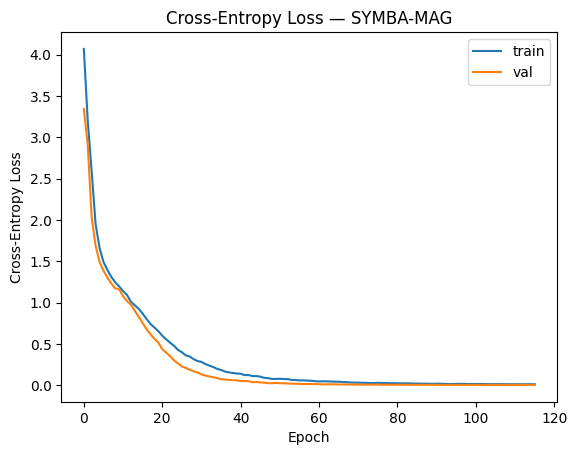

In [21]:
plt.plot(history['train_loss'], label='train')
plt.plot(history['val_loss'],   label='val')
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.title('Cross-Entropy Loss — SYMBA-MAG')
plt.legend()

plt.show()

## Evaluation

In [22]:
test_ds = SymbaSeq2SeqDataset(qcd_test, tok, vocab)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=_collate)

test_seq_acc, test_tok_acc = evaluate_accuracy(test_loader, n_batches=len(test_loader))

print(f"Test Sequence Accuracy (Exact Match): {test_seq_acc:.4f}")
print(f"Test Token Accuracy: {test_tok_acc:.4f}")

Normalizing DataFrame Pairs:   0%|          | 0/24 [00:00<?, ?it/s]

Encoding:   0%|          | 0/24 [00:00<?, ?it/s]

Test Sequence Accuracy (Exact Match): 0.9167
Test Token Accuracy: 0.8538
